In [12]:
import torch
import torch.nn as nn 
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

torch.manual_seed(0)
np.random.seed(0)

Using device: cpu


train: torch.Size([60000, 784]) labels: torch.Size([60000])
test: torch.Size([10000, 784]) labels: torch.Size([10000])


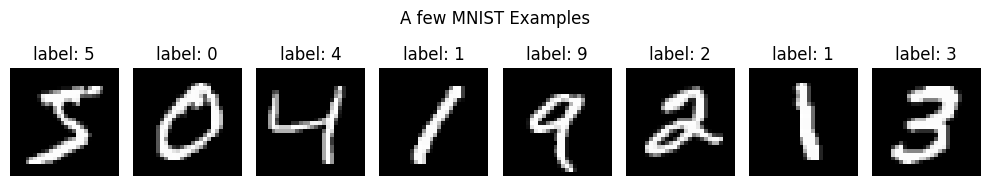

In [13]:
train_data = datasets.MNIST('./data',train=True,download=True)
test_data = datasets.MNIST('./data',train=False,download=True)

train_x = train_data.data.float().reshape(-1,784) / 255.0
train_y = train_data.targets
test_x = test_data.data.float().reshape(-1,784) / 255.0
test_y = test_data.targets

train_x, train_y = train_x.to(device), train_y.to(device)
test_x, test_y = test_x.to(device), test_y.to(device)

print(f'train: {train_x.shape} labels: {train_y.shape}')
print(f'test: {test_x.shape} labels: {test_y.shape}')

#show an example or two
fig, axes = plt.subplots(1,8,figsize=(10,2))
for i,ax in enumerate(axes):
    ax.imshow(train_x[i].cpu().reshape(28,28),cmap ='gray')
    ax.set_title(f'label: {train_y[i].item()}')
    ax.axis('off')
plt.suptitle("A few MNIST Examples")
plt.tight_layout()
plt.show()

In [14]:
class LogReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(784,10)
    def forward(self,x):
        return self.linear(x)

def train(model, train_x,train_y,n_epochs=5,batch_size=256,lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n_train = len(train_x)
    for epoch in range(n_epochs):
        perm = torch.randperm(n_train,device=train_x.device)
        running_loss = 0.0
        running_correct = 0.0
        for i in range(0,n_train,batch_size):
            idx = perm[i:i+batch_size]
            x,y=train_x[idx],train_y[idx]
            logits=model(x)
            loss = F.cross_entropy(logits,y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(x)
            running_correct += (logits.argmax(dim=1)==y).sum().item()
        print(f'epoch { epoch+1}/{n_epochs}  train loss {running_loss / n_train:.4f}  train acc { running_correct / n_train:.3f}')
logreg = LogReg().to(device)
train(logreg,train_x,train_y,n_epochs=5)

with torch.no_grad():
    test_acc=(logreg(test_x).argmax(dim=1)==test_y).float().mean().item()
print(f'Logistic regression test accuracy: {test_acc:.3f}')

epoch 1/5  train loss 0.8531  train acc 0.812
epoch 2/5  train loss 0.4255  train acc 0.890
epoch 3/5  train loss 0.3601  train acc 0.904
epoch 4/5  train loss 0.3301  train acc 0.910
epoch 5/5  train loss 0.3123  train acc 0.914
Logistic regression test accuracy: 0.918


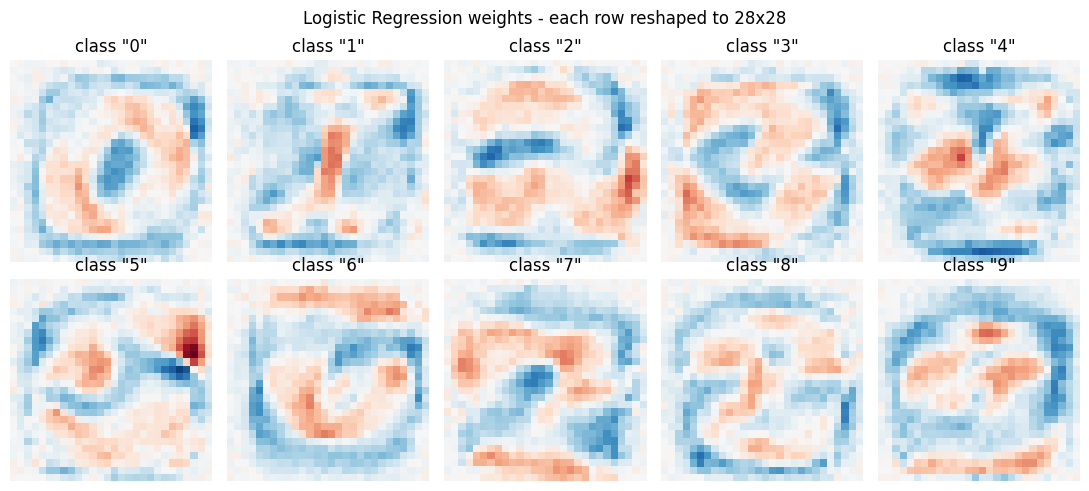

In [15]:
#visualizing the weights
W = logreg.linear.weight.detach().cpu().numpy()
vlim = np.abs(W).max()

fig, axes = plt.subplots(2,5,figsize=(11,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(W[i].reshape(28, 28), cmap='RdBu_r', vmin=-vlim, vmax=vlim)
    ax.set_title(f'class "{i}"')
    ax.axis('off')
plt.suptitle('Logistic Regression weights - each row reshaped to 28x28')
plt.tight_layout()
plt.show()

In [17]:
class MLP(nn.Module):
    def __init__(self, n_hidden=32):
        super().__init__()
        self.fc1 = nn.Linear(784,n_hidden)
        self.fc2 = nn.Linear(n_hidden,10)

    def forward(self,x):
        return self.fc2(F.relu(self.fc1(x)))
mlp = MLP(n_hidden=32).to(device)
train(mlp,train_x,train_y,n_epochs=5)

with torch.no_grad():
    test_acc = (mlp(test_x).argmax(dim=1)==test_y).float().mean().item()
print(f'\nMLP test accuracy: {test_acc:.3f}')

epoch 1/5  train loss 0.7585  train acc 0.821
epoch 2/5  train loss 0.3138  train acc 0.912
epoch 3/5  train loss 0.2655  train acc 0.926
epoch 4/5  train loss 0.2369  train acc 0.933
epoch 5/5  train loss 0.2134  train acc 0.939

MLP test accuracy: 0.941
